# 14 - Task 3: ablation under two CV protocols

The notebook that decides what ships.

**The idea in one line.** Score every feature family twice, once under the standard
stratified CV this project has always used and once under leave-one-cluster-out CV, and
treat the difference as a measurement of how much of that family's apparent value is
domain memorisation rather than transferable signal.

| column | meaning |
|---|---|
| `cv_standard` | locked 5-fold stratified CV, trains and tests on the same domains |
| `cv_grouped` | leave-one-cluster-out, tests on a document type never trained on |
| `transfer_gap` | `cv_standard - cv_grouped`, large means domain-dependent |

**The selection rule, fixed here before any result exists: ship on `cv_grouped`.** A
family with a large `transfer_gap` is dropped even if it tops the standard table.

This is round 4's lesson applied one level up. There, held-out AUC ranked `meta/gbm`
first and `weights/hill_climb` sixth, a 0.0004 separation well inside the bar; the
optimism gap separated them by a factor of 40, and on Kaggle the low-gap combiner gained
eight times more. The mean did not predict transfer and the gap did. Same structure here,
one level further out: `cv_standard` is the flattering number and `cv_grouped` is the one
that has to be earned.

## 0. Setup

In [1]:
# Reload src/ helpers on every cell execution. Round 5 adds src/text.py,
# src/text_features.py and src/clustering.py while these notebooks are open, and a
# plain `import` caches the module in the kernel - so a fixed helper keeps failing
# with the OLD traceback until the kernel is restarted. With this, saving the .py
# is enough.
%load_ext autoreload
%autoreload 2

# Adds project root to path so `import src...` works from notebooks/.
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import paths, data, evaluation, tuning, ensemble, text
from src import text_features as tf
from src import clustering
from src.paths import FIGURES
FIGURES.mkdir(parents=True, exist_ok=True)

from scipy import sparse as sp
from sklearn.base import clone
from sklearn.model_selection import cross_val_score
from lightgbm import LGBMClassifier

## 1. Load the blocks, the split, and the clusters

The cluster metadata is checked before use. If notebook 13's stability gate failed, this
notebook's grouped protocol is not trustworthy and the cell says so rather than carrying
on quietly.

In [2]:
train_ids, train_texts, y = text.load_train_text()
dev_idx = np.load(paths.DATA_PROCESSED / "dev_idx.npy")
y_dev = y[dev_idx]
cv_standard = evaluation.make_cv()

built = tf.load_blocks(tf.ALL_BLOCKS)
X_supplied, _, _ = data.load_train_features(sparse=True)

clusters = np.load(paths.DATA_PROCESSED / "domain_clusters.npz")
meta = json.loads((paths.DATA_PROCESSED / "domain_clusters.json").read_text())
dev_clusters = clusters["dev_labels"]

print(json.dumps(meta, indent=2))
assert meta["stable"], (
    "notebook 13's stability gate failed - the grouped protocol would measure noise. "
    "Either re-run 13 with a different K, or drop the transfer analysis and say so.")
print("\nstability gate passed, grouped protocol is usable")

{
  "k": 3,
  "min_ari": 0.9702842716401743,
  "stable": true,
  "mean_purity_vs_id_group": 0.6937538030610888,
  "machine_share_std": 0.04856134407566119,
  "per_cluster_share_enabled": false,
  "svd_explained_variance": 1.0000001192092896,
  "train_sizes": {
    "0": 4215,
    "1": 6126,
    "2": 9659
  }
}

stability gate passed, grouped protocol is usable


In [3]:
folds_grouped, skipped = clustering.cluster_cv(dev_clusters, y_dev)
print(f"{len(folds_grouped)} usable leave-one-cluster-out folds")
for i, (tr, te) in enumerate(folds_grouped):
    print(f"  fold {i}: train {len(tr):5d}  held out {len(te):5d}  "
          f"held-out machine share {y_dev[te].mean():.3f}")

if len(skipped):
    print("\nskipped clusters (too small or too single-class to score macro F1 on):")
    print(skipped.to_string(index=False))

3 usable leave-one-cluster-out folds
  fold 0: train 12641  held out  3359  held-out machine share 0.691
  fold 1: train 11079  held out  4921  held-out machine share 0.628
  fold 2: train  8280  held out  7720  held-out machine share 0.595


## 2. The candidate feature set

The starting point is whatever notebook 12 found best. Set it here explicitly rather than
reading it from the table, so this notebook records what it actually tested.

One model throughout, at default hyperparameters. This measures features, and letting the
model vary would confound the two.

In [4]:
# From 12 section 6. Change if the merged table says otherwise.
BASE_BLOCKS = list(tf.ALL_BLOCKS)
INCLUDE_SUPPLIED = True

ME = "cliffton"   # <-- THE ONLY LINE TO CHANGE


def assemble(blocks, include_supplied=INCLUDE_SUPPLIED, rows=None):
    '''Stack the named blocks (plus the supplied TF-IDF) for the given rows.'''
    rows = dev_idx if rows is None else rows
    parts = []
    if include_supplied:
        parts.append(X_supplied[rows])
    if blocks:
        parts.append(tf.stack(built, blocks)[0][rows])
    assert parts, "no features selected"
    return sp.hstack(parts, format="csr") if len(parts) > 1 else parts[0]


def make_model():
    return LGBMClassifier(class_weight="balanced", verbose=-1, n_jobs=-1,
                          random_state=42)


X_full = assemble(BASE_BLOCKS)
print(f"full candidate: {X_full.shape}")
print(f"blocks: {BASE_BLOCKS}")
print(f"supplied TF-IDF included: {INCLUDE_SUPPLIED}")

full candidate: (16000, 45390)
blocks: ['A_function_words', 'B_punctuation', 'C_casing', 'D_structure', 'E_length', 'F_diversity', 'G_readability', 'H_char_ngrams', 'I_word_ngrams']
supplied TF-IDF included: True


## 3. Scoring under both protocols

`cv_grouped` is the expensive one: each fold trains on all but one cluster, and the folds
are unequal, so a mean over them is not the same estimator as a stratified mean. That is
intentional. It is also why the per-fold spread is reported rather than just the mean; a
grouped score with a huge spread across domains is telling you something a single number
hides.

In [5]:
def score_both(X, y_, tag):
    '''Macro F1 under both protocols, cached through the trial ledger.'''
    std = cross_val_score(make_model(), X, y_, cv=cv_standard,
                          scoring="f1_macro", n_jobs=1)
    grp = []
    for tr, te in folds_grouped:
        m = clone(make_model()).fit(X[tr], y_[tr])
        grp.append(evaluation.macro_f1(y_[te], m.predict(X[te])))
    grp = np.array(grp)
    return {"config": tag,
            "cv_standard": float(std.mean()), "std_standard": float(std.std()),
            "cv_grouped": float(grp.mean()), "std_grouped": float(grp.std()),
            "transfer_gap": float(std.mean() - grp.mean()),
            "grouped_folds": [float(v) for v in grp]}


full = score_both(X_full, y_dev, "full")
print(f"full model")
print(f"  standard {full['cv_standard']:.4f} +/- {full['std_standard']:.4f}")
print(f"  grouped  {full['cv_grouped']:.4f} +/- {full['std_grouped']:.4f}")
print(f"  transfer gap {full['transfer_gap']:+.4f}")
print(f"  per-fold grouped: {np.round(full['grouped_folds'], 4).tolist()}")

full model
  standard 0.8795 +/- 0.0053
  grouped  0.7864 +/- 0.0803
  transfer gap +0.0931
  per-fold grouped: [0.8838, 0.7882, 0.6871]


## 4. Leave one family out

Drop one block at a time and re-score. The drop in `cv_grouped` is what that family is
worth *for transfer*; the drop in `cv_standard` is what it is worth in-domain. A family
that matters under standard CV and not under grouped CV is a domain detector, and it will
not help on a test set drawn from domains it has never seen.

The supplied TF-IDF is included as a droppable family, so the notebook can answer whether
it is worth keeping at all once style features are present.

In [6]:
FAMILIES = [(b, b) for b in BASE_BLOCKS]
if INCLUDE_SUPPLIED:
    FAMILIES.append(("tfidf_supplied", None))

rows = [full | {"dropped": "(none)"}]
for label, block in FAMILIES:
    keep = [b for b in BASE_BLOCKS if b != block]
    include = INCLUDE_SUPPLIED and label != "tfidf_supplied"
    if not keep and not include:
        continue
    X = assemble(keep, include_supplied=include)
    r = score_both(X, y_dev, f"drop_{label}")
    r["dropped"] = label
    rows.append(r)
    print(f"drop {label:20s} standard {r['cv_standard']:.4f}  "
          f"grouped {r['cv_grouped']:.4f}  gap {r['transfer_gap']:+.4f}", flush=True)

ablation = pd.DataFrame(rows)
for col, base in [("standard", "cv_standard"), ("grouped", "cv_grouped")]:
    ablation[f"loss_{col}"] = ablation[base].iloc[0] - ablation[base]
ablation.to_csv(paths.DATA_PROCESSED / "ablation_results.csv", index=False)

drop A_function_words     standard 0.8793  grouped 0.7862  gap +0.0931
drop B_punctuation        standard 0.8793  grouped 0.7853  gap +0.0940
drop C_casing             standard 0.8769  grouped 0.7735  gap +0.1035
drop D_structure          standard 0.8692  grouped 0.7851  gap +0.0841
drop E_length             standard 0.8723  grouped 0.7686  gap +0.1037
drop F_diversity          standard 0.8624  grouped 0.7354  gap +0.1270
drop G_readability        standard 0.8784  grouped 0.7865  gap +0.0920
drop H_char_ngrams        standard 0.8623  grouped 0.7565  gap +0.1058
drop I_word_ngrams        standard 0.8758  grouped 0.7740  gap +0.1018
drop tfidf_supplied       standard 0.8814  grouped 0.7938  gap +0.0876


## 5. The transfer table

`loss_grouped` is the column that decides what ships: how much held-out-domain Macro F1
is given up by removing that family. A family with `loss_grouped` at or below zero is one
the model is better off without when facing a new domain.

In [7]:
view = (ablation[["dropped", "cv_standard", "cv_grouped", "transfer_gap",
                  "loss_standard", "loss_grouped"]]
        .sort_values("loss_grouped", ascending=False))
print(view.round(4).to_string(index=False))

body = ablation[ablation["dropped"] != "(none)"]
disagree = body[(body["loss_standard"] > 0.002) & (body["loss_grouped"] <= 0)]
if len(disagree):
    print("\nFamilies that help in-domain but NOT across domains - these are domain "
          "detectors and should be dropped despite a good standard-CV number:")
    print(disagree[["dropped", "loss_standard", "loss_grouped"]].round(4)
          .to_string(index=False))
else:
    print("\nNo family shows the memorisation signature; the two protocols agree.")

         dropped  cv_standard  cv_grouped  transfer_gap  loss_standard  loss_grouped
     F_diversity       0.8624      0.7354        0.1270         0.0171        0.0510
   H_char_ngrams       0.8623      0.7565        0.1058         0.0172        0.0299
        E_length       0.8723      0.7686        0.1037         0.0071        0.0177
        C_casing       0.8769      0.7735        0.1035         0.0026        0.0129
   I_word_ngrams       0.8758      0.7740        0.1018         0.0037        0.0123
     D_structure       0.8692      0.7851        0.0841         0.0102        0.0012
   B_punctuation       0.8793      0.7853        0.0940         0.0002        0.0011
A_function_words       0.8793      0.7862        0.0931         0.0001        0.0002
          (none)       0.8795      0.7864        0.0931         0.0000        0.0000
   G_readability       0.8784      0.7865        0.0920         0.0010       -0.0001
  tfidf_supplied       0.8814      0.7938        0.0876        -0

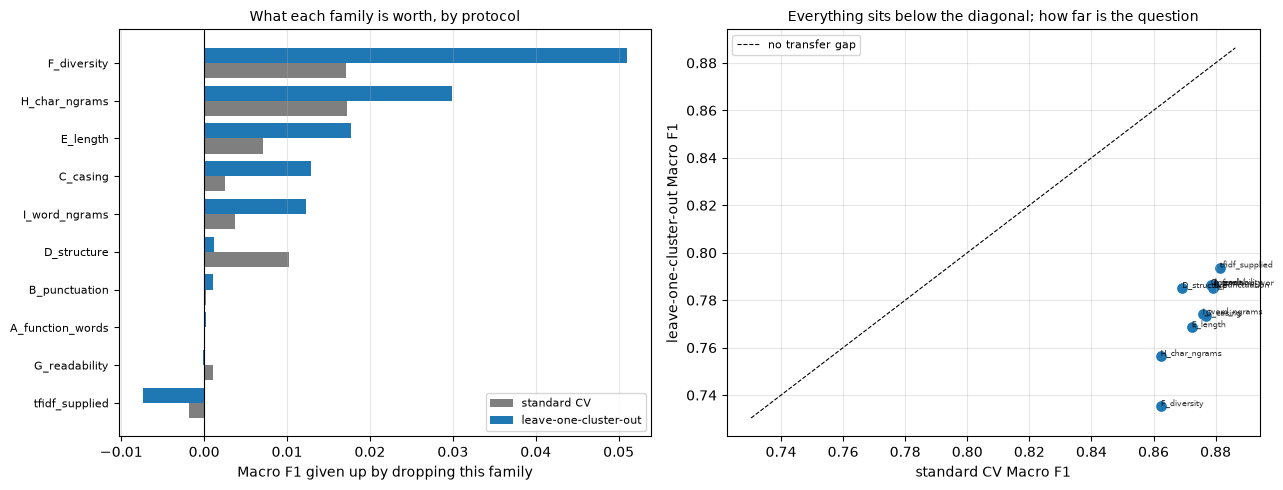

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

b = body.sort_values("loss_grouped")
idx = np.arange(len(b))
axes[0].barh(idx - 0.2, b["loss_standard"], height=0.4, label="standard CV",
             color="tab:gray")
axes[0].barh(idx + 0.2, b["loss_grouped"], height=0.4, label="leave-one-cluster-out",
             color="tab:blue")
axes[0].set_yticks(idx, b["dropped"], fontsize=8)
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_xlabel("Macro F1 given up by dropping this family")
axes[0].set_title("What each family is worth, by protocol", fontsize=10)
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3, axis="x")

axes[1].scatter(ablation["cv_standard"], ablation["cv_grouped"], s=45)
lims = [min(ablation["cv_grouped"].min(), ablation["cv_standard"].min()) - 0.005,
        ablation["cv_standard"].max() + 0.005]
axes[1].plot(lims, lims, "k--", lw=0.8, label="no transfer gap")
for _, r in ablation.iterrows():
    axes[1].annotate(str(r["dropped"])[:14], (r["cv_standard"], r["cv_grouped"]),
                     fontsize=6, alpha=0.8)
axes[1].set_xlabel("standard CV Macro F1")
axes[1].set_ylabel("leave-one-cluster-out Macro F1")
axes[1].set_title("Everything sits below the diagonal; how far is the question",
                  fontsize=10)
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / "ablation_transfer.png", dpi=120)
plt.show()

## 6. Permutation importance on the dense families

Blocks B to G are about 60 named columns in total, small enough for permutation
importance to be meaningful and readable by name. This is the part of round 5 that
produces sentences for the report rather than table rows: "machine text has lower
sentence-length variance" is worth more to a reader than a feature index.

Computed on the held-out fold of a grouped split, so the importances describe transfer
rather than in-domain fit.

In [9]:
from sklearn.inspection import permutation_importance

DENSE = list(tf.DENSE_BLOCKS)
X_dense_tr, _, dense_names = tf.stack(built, DENSE)
X_dense = X_dense_tr[dev_idx].toarray()

tr, te = folds_grouped[0]
model = make_model().fit(X_dense[tr], y_dev[tr])
print(f"held-out cluster fold: {len(te)} rows, "
      f"macro F1 {evaluation.macro_f1(y_dev[te], model.predict(X_dense[te])):.4f}")

imp = permutation_importance(model, X_dense[te], y_dev[te], n_repeats=5,
                             random_state=42, scoring="f1_macro", n_jobs=-1)
top = (pd.DataFrame({"feature": dense_names, "importance": imp.importances_mean,
                     "std": imp.importances_std})
       .sort_values("importance", ascending=False).head(20).reset_index(drop=True))
print()
print(top.round(5).to_string(index=False))

held-out cluster fold: 3359 rows, macro F1 0.7789

              feature  importance     std
           B_punct_59     0.02431 0.00099
         E_burstiness     0.01964 0.00272
       E_sent_len_std     0.01468 0.00162
C_titlecase_word_frac     0.01215 0.00265
       D_line_len_std     0.01080 0.00182
            D_n_lines     0.00919 0.00230
        D_bullet_frac     0.00916 0.00234
           E_log_word     0.00674 0.00167
                F_ttr     0.00595 0.00226
           B_punct_40     0.00546 0.00102
           B_punct_41     0.00533 0.00134
          F_mattr_100     0.00462 0.00127
      E_para_len_mean     0.00434 0.00102
            F_yules_k     0.00389 0.00216
           B_punct_58     0.00371 0.00108
           B_punct_95     0.00343 0.00049
       E_word_len_std     0.00284 0.00107
       D_line_len_max     0.00281 0.00210
           B_punct_33     0.00234 0.00103
           B_punct_39     0.00211 0.00108


## 7. The chosen feature set

Applying the rule from the top of the notebook: keep every family with a positive
`loss_grouped`, drop the rest. Stated as code so the decision is reproducible rather than
a judgement made while reading a table.

In [10]:
KEEP = [r["dropped"] for _, r in body.iterrows()
        if r["loss_grouped"] > 0 and r["dropped"] != "tfidf_supplied"]
KEEP_SUPPLIED = bool(
    INCLUDE_SUPPLIED and
    body.loc[body["dropped"] == "tfidf_supplied", "loss_grouped"].gt(0).all())

print(f"keep blocks:        {KEEP}")
print(f"keep supplied TFIDF: {KEEP_SUPPLIED}")

X_chosen = assemble(KEEP, include_supplied=KEEP_SUPPLIED)
chosen = score_both(X_chosen, y_dev, "chosen")
print(f"\nchosen set {X_chosen.shape}")
print(f"  standard {chosen['cv_standard']:.4f}   grouped {chosen['cv_grouped']:.4f}")
print(f"  full set standard {full['cv_standard']:.4f}   "
      f"grouped {full['cv_grouped']:.4f}")

baseline_grouped = score_both(assemble([], include_supplied=True), y_dev,
                              "supplied_only")
print(f"  supplied only     standard {baseline_grouped['cv_standard']:.4f}   "
      f"grouped {baseline_grouped['cv_grouped']:.4f}")

gain = chosen["cv_grouped"] - baseline_grouped["cv_grouped"]
print(f"\ntransfer gain over the supplied features alone: {gain:+.4f}")
print("Grouped-CV fold spread is large by construction, so compare this against "
      f"the fold std of {chosen['std_grouped']:.4f}, not against 0.")

json.dump({"keep_blocks": KEEP, "keep_supplied": KEEP_SUPPLIED,
           "chosen": chosen, "full": full, "supplied_only": baseline_grouped},
          open(paths.DATA_PROCESSED / "chosen_features.json", "w"), indent=2)

keep blocks:        ['A_function_words', 'B_punctuation', 'C_casing', 'D_structure', 'E_length', 'F_diversity', 'H_char_ngrams', 'I_word_ngrams']
keep supplied TFIDF: False

chosen set (16000, 40385)
  standard 0.8764   grouped 0.7898
  full set standard 0.8795   grouped 0.7864
  supplied only     standard 0.7303   grouped 0.6910

transfer gain over the supplied features alone: +0.0988
Grouped-CV fold spread is large by construction, so compare this against the fold std of 0.0708, not against 0.


## 8. Fit and submit

One submission. The chosen feature set, fitted on all 20,000 rows, thresholded with
notebook 11's per-group shares if those turned out to help and the global 0.4996
otherwise.

Only one file, because the point of round 5 is to test whether the *representation*
moves the score. Two variants of the same representation would spend a slot on a
difference already known to be inside the noise floor.

In [11]:
test_ids, test_texts = text.load_test_text()
X_supplied_test, test_ids_feat = data.load_test_features(sparse=True)
assert list(test_ids_feat) == list(test_ids)

parts_tr, parts_te = [], []
if KEEP_SUPPLIED:
    parts_tr.append(X_supplied); parts_te.append(X_supplied_test)
if KEEP:
    a, b, _ = tf.stack(built, KEEP)
    parts_tr.append(a); parts_te.append(b)

X_tr = sp.hstack(parts_tr, format="csr") if len(parts_tr) > 1 else parts_tr[0]
X_te = sp.hstack(parts_te, format="csr") if len(parts_te) > 1 else parts_te[0]
assert X_tr.shape[1] == X_te.shape[1]

model = make_model().fit(X_tr, y)
scores = ensemble.member_score(model, X_te)
print(f"fitted on {X_tr.shape}, scored {X_te.shape}")

fitted on (20000, 40385), scored (6999, 40385)


In [12]:
# Per-group shares from notebook 11, used only if that experiment came back positive.
USE_PER_GROUP = False        # set from notebook 11's Kaggle result
PER_GROUP = {"uuid": 0.56, "numeric": 0.475}
BENCH_SHARE = 0.4996

groups_test = text.id_group(test_ids)
if USE_PER_GROUP:
    preds = clustering.threshold_per_group(scores, groups_test, PER_GROUP)
    fname = "round5_features_pergroup.csv"
else:
    preds = ensemble.threshold_at_share(scores, BENCH_SHARE)
    fname = "round5_features_share50.csv"

data.write_submission(test_ids, preds, fname)

sample = pd.read_csv(paths.DATA_RAW / "sample_submission.csv", dtype={"id": str})
sub = pd.read_csv(paths.SUBMISSIONS / fname, dtype={"id": str})
assert list(sub.columns) == ["id", "label"]
assert list(sub["id"]) == list(sample["id"]), "id order drifted"
assert set(sub["label"].unique()) <= {0, 1}

bench_file = paths.SUBMISSIONS / "ensemble_weights_hill_climb_share50.csv"
if bench_file.exists():
    bench = pd.read_csv(bench_file)["label"].to_numpy()
    print(f"{fname}: share {sub['label'].mean():.4f}, "
          f"{int((sub['label'].to_numpy() != bench).sum())} rows differ from the "
          "0.73754 benchmark")
print("\nUnder ~200 differing rows the comparison is under-powered against the 0.0084 "
      "noise floor.")

round5_features_share50.csv: share 0.4996, 1422 rows differ from the 0.73754 benchmark

Under ~200 differing rows the comparison is under-powered against the 0.0084 noise floor.


## Discussion / carry-forward -> Task 4 report

**Result.** K = 3 produced stable document-style clusters (minimum ARI 0.9703), so
leave-one-cluster-out validation was usable. The full raw-text representation scored
0.8795 +/- 0.0053 under standard CV but 0.7864 +/- 0.0803 when one cluster was held
out: a transfer gap of 0.0931. The grouped folds (0.8838, 0.7882, 0.6871) show that
document types genuinely differ in difficulty.

**What transfers.** Diversity was the strongest family for the unseen-cluster test
(dropping it cost 0.0510 Macro F1), followed by character n-grams (0.0299), length
(0.0177), casing (0.0129), and word n-grams (0.0123). Readability did not help
(-0.0001), and removing the supplied TF-IDF improved grouped F1 by 0.0074. No family
had the memorisation signature of helping standard CV while failing grouped CV.

**Chosen representation.** Keep A-F and H-I; drop G readability and the supplied
TF-IDF. This 40,385-feature representation scored 0.8764 under standard CV and 0.7898
under grouped CV, compared with 0.7303 and 0.6910 respectively for supplied TF-IDF
alone. The grouped transfer gain is +0.0988, but the three-fold grouped spread is
0.0708, so it is strong evidence rather than a guaranteed Kaggle gain.

**Interpretability.** The most predictive dense style markers on one held-out cluster
included a punctuation feature, sentence-length burstiness and variability, title-case
rate, line-length variability, and number of lines. These are predictive signals, not
directions of effect, so they should not be described as universally human or machine.

**Submission status.** `round5_features_share50.csv` was generated from a LightGBM fit
on all 20,000 labelled rows. It differs from the previous benchmark on 1,422 of 6,999
test rows, so it is a meaningfully different submission. Kaggle submission slots were
exhausted before it could be scored; therefore no leaderboard improvement is claimed.

**Not pursued.** Per-cluster prediction shares remain disabled: the clusters are stable
but did not meet the ID-group purity or class-balance-variation gates.